In [43]:
import warnings
warnings.filterwarnings("ignore")

In [44]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [45]:
from google.colab import files

uploaded = files.upload()

Saving Iris.csv to Iris (1).csv


In [46]:
df = pd.read_csv('Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [28]:
print(df.shape)

print(df.info())

print(df['Species'].value_counts())

(150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [47]:
X = df.drop(['Id', 'Species'], axis=1)

y = df['Species']

In [48]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(y[:10])

[0 0 0 0 0 0 0 0 0 0]


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [51]:
y_pred = model.predict(X_test)

print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [52]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [54]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("Predicted Class:", prediction)

Predicted Class: [0]


In [55]:
print(encoder.inverse_transform(prediction))

['Iris-setosa']


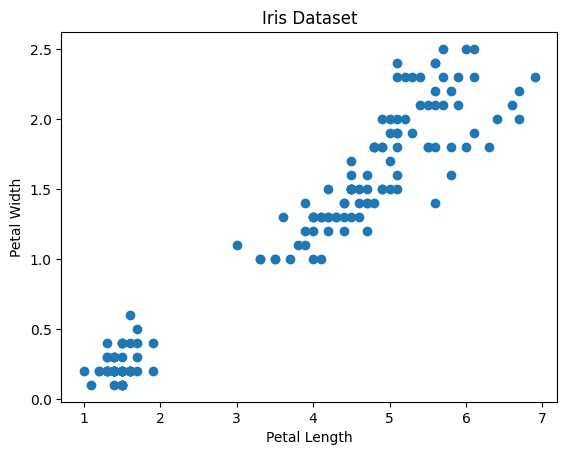

In [56]:
import matplotlib.pyplot as plt

plt.scatter(
    df['PetalLengthCm'],
    df['PetalWidthCm']
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Dataset")
plt.show()